# Avance 2: Desarrollo del Proyecto

Eduardo Veytia

Dayanni Godoy 

### Protective Put - SMH

In [1]:
# SECCION 1: IMPORTACIONES Y CONFIGURACION
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4
plt.rcParams['font.family'] = 'DejaVu Sans'

print("  PROTECTIVE PUT - SMH (VanEck Semiconductor ETF)")

  PROTECTIVE PUT - SMH (VanEck Semiconductor ETF)


In [2]:
# SECCION 2: DESCARGA DE DATOS CON YFINANCE
print("\n[1/6] Descargando datos de SMH desde Yahoo Finance...")

ticker = "SMH"
data = yf.download(ticker, start="2023-01-01", auto_adjust=True, progress=False)
data = data[['Close']].copy()
data.columns = ['Close']
data.dropna(inplace=True)

S0 = float(data['Close'].iloc[-1])
fecha_actual = data.index[-1].strftime('%Y-%m-%d')

print(f"  Ticker       : {ticker}")
print(f"  Fecha actual : {fecha_actual}")
print(f"  Precio actual: ${S0:.2f}")
print(f"  Registros    : {len(data)} dias de trading")



[1/6] Descargando datos de SMH desde Yahoo Finance...
  Ticker       : SMH
  Fecha actual : 2026-04-30
  Precio actual: $506.72
  Registros    : 834 dias de trading


In [3]:
# SECCION 3: VOLATILIDAD HISTORICA
print("\n[2/6] Calculando volatilidad historica...")

data['log_ret'] = np.log(data['Close'] / data['Close'].shift(1))
data.dropna(inplace=True)

vol_A  = float(data['log_ret'].tail(252).std()  * np.sqrt(252))
vol_B  = float(data['log_ret'].tail(756).std()  * np.sqrt(252))
vol_C = float(data['log_ret'].tail(1260).std() * np.sqrt(252))

print(f"  Volatilidad 1 año  (1A): {vol_A*100:.2f}%")
print(f"  Volatilidad 3 años  (3A): {vol_B*100:.2f}%")
print(f"  Volatilidad 5 años (5A): {vol_C*100:.2f}%")

sigma = vol_C  # Usamos 5 años como referencia principal
print(f"\n  -> Volatilidad seleccionada (5A): {sigma*100:.2f}%")




[2/6] Calculando volatilidad historica...
  Volatilidad 1 año  (1A): 29.54%
  Volatilidad 3 años  (3A): 34.14%
  Volatilidad 5 años (5A): 33.75%

  -> Volatilidad seleccionada (5A): 33.75%


In [4]:
# SECCION 4: PARAMETROS DE LA ESTRATEGIA
print("\n[3/6] Definiendo parametros de la estrategia...")

N_ACCIONES = 100           # Numero de acciones en el portafolio
T          = 1260 / 252      # Vencimiento: 1260 dias calendario (~5 anios)
r          = 0.0525        # Tasa libre de riesgo (Fed Funds aprox. 2025)
K          = round(S0 * 0.95, 0)  # Strike ~5% abajo del spot (ligeramente OTM)

print(f"  Acciones en portafolio : {N_ACCIONES}")
print(f"  Precio spot (S0)       : ${S0:.2f}")
print(f"  Strike put (K)         : ${K:.2f}  ({((K/S0)-1)*100:.1f}% vs. spot)")
print(f"  Vencimiento (T)        : {int(T*252)} dias  ({T:.4f} anos)")
print(f"  Tasa libre de riesgo   : {r*100:.2f}%")
print(f"  Volatilidad (sigma)    : {sigma*100:.2f}%")



[3/6] Definiendo parametros de la estrategia...
  Acciones en portafolio : 100
  Precio spot (S0)       : $506.72
  Strike put (K)         : $481.00  (-5.1% vs. spot)
  Vencimiento (T)        : 1260 dias  (5.0000 anos)
  Tasa libre de riesgo   : 5.25%
  Volatilidad (sigma)    : 33.75%


In [5]:
# SECCION 5: MODELO BLACK-SCHOLES
print("\n[4/6] Valuando la put con Black-Scholes...")

def black_scholes_put(S, K, T, r, sigma):
    """Precio teorico de una put europea (Black-Scholes)."""
    if T <= 0:
        return max(K - S, 0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    put_price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return put_price

def greeks_put(S, K, T, r, sigma):
    """Griegas de la put europea."""
    if T <= 0:
        return {'delta': 0, 'gamma': 0, 'theta': 0, 'vega': 0, 'rho': 0}
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    delta = -norm.cdf(-d1)
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    theta = (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
             + r * K * np.exp(-r * T) * norm.cdf(-d2)) / 252
    vega  = S * norm.pdf(d1) * np.sqrt(T) / 100
    rho   = -K * T * np.exp(-r * T) * norm.cdf(-d2) / 100
    return {'delta': delta, 'gamma': gamma,
            'theta': theta, 'vega': vega, 'rho': rho}

put_price = black_scholes_put(S0, K, T, r, sigma)
greeks    = greeks_put(S0, K, T, r, sigma)

costo_total_put  = put_price * N_ACCIONES
valor_portafolio = S0 * N_ACCIONES
costo_seguro_pct = (put_price / S0) * 100

print(f"\n  Prima teorica (Black-Scholes) : ${put_price:.4f} por accion")
print(f"  Costo total de la put         : ${costo_total_put:.2f} ({N_ACCIONES} acciones)")
print(f"  Costo del seguro              : {costo_seguro_pct:.2f}% del valor del ETF")
print(f"  Valor del portafolio          : ${valor_portafolio:.2f}")

print("\n  -- GRIEGAS -")
print(f"  Delta : {greeks['delta']:.4f}")
print(f"  Gamma : {greeks['gamma']:.6f}")
print(f"  Theta : {greeks['theta']:.4f}  (perdida diaria por time decay)")
print(f"  Vega  : {greeks['vega']:.4f}  (cambio en prima por +1% de vol)")
print(f"  Rho   : {greeks['rho']:.4f}  (cambio en prima por +1% en tasa)")



[4/6] Valuando la put con Black-Scholes...

  Prima teorica (Black-Scholes) : $70.9232 por accion
  Costo total de la put         : $7092.32 (100 acciones)
  Costo del seguro              : 14.00% del valor del ETF
  Valor del portafolio          : $50672.00

  -- GRIEGAS -
  Delta : -0.2135
  Gamma : 0.000761
  Theta : -0.0068  (perdida diaria por time decay)
  Vega  : 3.2976  (cambio en prima por +1% de vol)
  Rho   : -8.9564  (cambio en prima por +1% en tasa)


In [6]:
# SECCION 6: SIMULACION MONTE CARLO
print("\n[5/6] Ejecutando simulacion Monte Carlo...")

np.random.seed(42)
N_SIM   = 50_000
N_STEPS = int(T * 252)
dt      = T / N_STEPS

Z       = np.random.standard_normal((N_STEPS, N_SIM))
log_ret = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
S_paths = S0 * np.exp(np.cumsum(log_ret, axis=0))
S_paths = np.vstack([np.full(N_SIM, S0), S_paths])

S_T = S_paths[-1]

# Payoffs al vencimiento
payoff_put        = np.maximum(K - S_T, 0)
payoff_stock      = S_T - S0
payoff_protective = payoff_stock + payoff_put - put_price

precio_mc  = float(np.mean(payoff_put) * np.exp(-r * T))
p_correc   = float(np.mean(S_T < S0) * 100)
p_put_itm  = float(np.mean(S_T < K) * 100)
retorno_pp = float(np.mean(payoff_protective))
var_95     = float(np.percentile(payoff_protective, 5))
cvar_95    = float(np.mean(payoff_protective[payoff_protective <= var_95]))
max_loss   = float(-(put_price + max(S0 - K, 0)))

print(f"  Simulaciones             : {N_SIM:,}")
print(f"  Precio MC de la put      : ${precio_mc:.4f}  (BS: ${put_price:.4f})")
print(f"  Prob. caida vs. hoy      : {p_correc:.1f}%")
print(f"  Prob. put ITM al vto.    : {p_put_itm:.1f}%")
print(f"  Retorno esperado (PP)    : ${retorno_pp:.2f} por accion")
print(f"  VaR 95%                  : ${var_95:.2f} por accion")
print(f"  CVaR 95%                 : ${cvar_95:.2f} por accion")
print(f"  Perdida max. teorica     : ${max_loss:.2f} por accion")



[5/6] Ejecutando simulacion Monte Carlo...
  Simulaciones             : 50,000
  Precio MC de la put      : $72.0079  (BS: $70.9232)
  Prob. caida vs. hoy      : 51.8%
  Prob. put ITM al vto.    : 49.0%
  Retorno esperado (PP)    : $169.82 por accion
  VaR 95%                  : $-96.64 por accion
  CVaR 95%                 : $-96.64 por accion
  Perdida max. teorica     : $-96.64 por accion



[6/6] Generando visualizaciones...


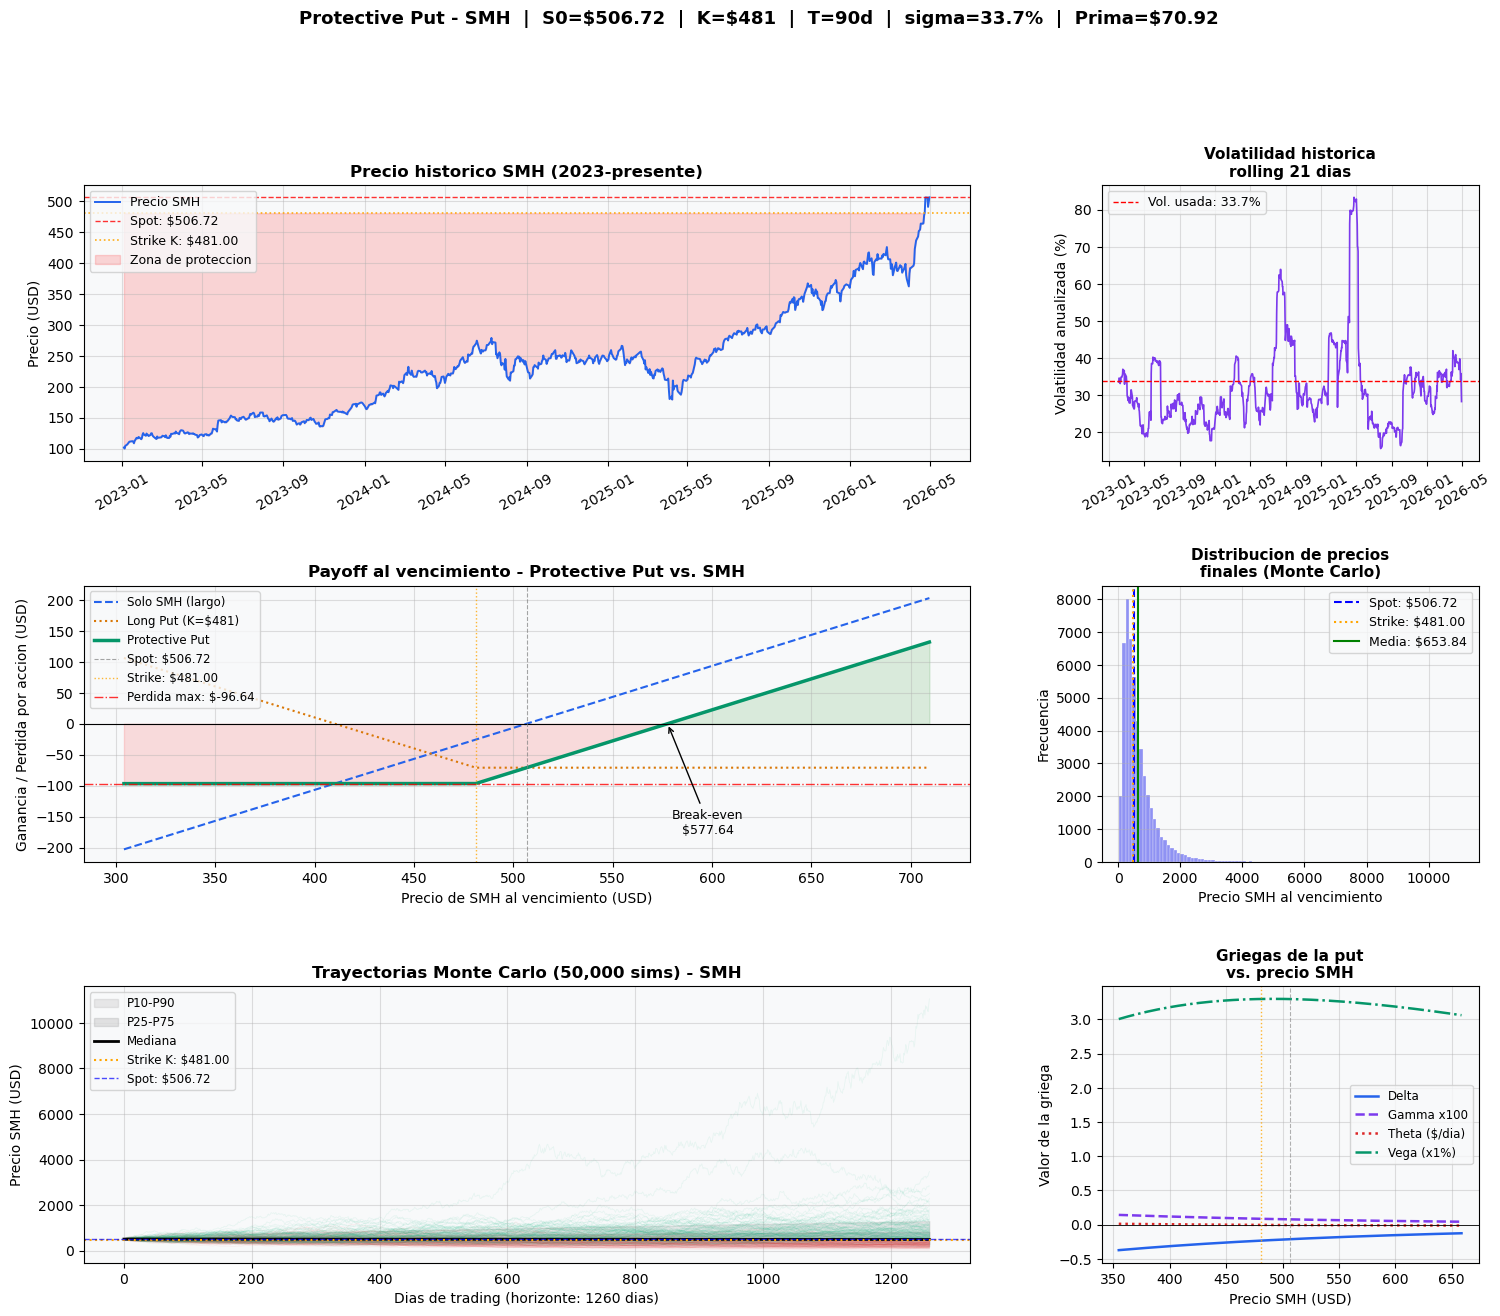


  Figura guardada como: protective_put_SMH.png


In [7]:
# SECCION 7: VISUALIZACIONES
print("\n[6/6] Generando visualizaciones...")

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :2])
ax2 = fig.add_subplot(gs[0, 2])
ax3 = fig.add_subplot(gs[1, :2])
ax4 = fig.add_subplot(gs[1, 2])
ax5 = fig.add_subplot(gs[2, :2])
ax6 = fig.add_subplot(gs[2, 2])

# -- GRAFICA 1: Precio historico 
ax1.plot(data.index, data['Close'], color='#2563EB', linewidth=1.4, label='Precio SMH')
ax1.axhline(S0, color='red',    linestyle='--', linewidth=1,   alpha=0.8, label=f'Spot: ${S0:.2f}')
ax1.axhline(K,  color='orange', linestyle=':',  linewidth=1.2, alpha=0.9, label=f'Strike K: ${K:.2f}')
ax1.fill_between(data.index, data['Close'], K,
                 where=(data['Close'] < K), alpha=0.15, color='red', label='Zona de proteccion')
ax1.set_title('Precio historico SMH (2023-presente)', fontweight='bold', fontsize=12)
ax1.set_ylabel('Precio (USD)')
ax1.legend(fontsize=9, loc='upper left')
ax1.tick_params(axis='x', rotation=30)

# -- GRAFICA 2: Volatilidad rolling 21 dias 
vol_roll = data['log_ret'].rolling(21).std() * np.sqrt(252) * 100
ax2.plot(vol_roll.index, vol_roll, color='#7C3AED', linewidth=1.2)
ax2.axhline(sigma * 100, color='red', linestyle='--', linewidth=1,
            label=f'Vol. usada: {sigma*100:.1f}%')
ax2.set_title('Volatilidad historica\nrolling 21 dias', fontweight='bold', fontsize=11)
ax2.set_ylabel('Volatilidad anualizada (%)')
ax2.legend(fontsize=9)
ax2.tick_params(axis='x', rotation=30)

# -- GRAFICA 3: Payoff al vencimiento 
S_range = np.linspace(S0 * 0.6, S0 * 1.4, 500)

pnl_stock_arr      = S_range - S0
pnl_put_arr        = np.maximum(K - S_range, 0) - put_price
pnl_protective_arr = pnl_stock_arr + pnl_put_arr

ax3.plot(S_range, pnl_stock_arr,      '--', color='#2563EB', lw=1.5, label='Solo SMH (largo)')
ax3.plot(S_range, pnl_put_arr,        ':',  color='#D97706', lw=1.5, label=f'Long Put (K=${K:.0f})')
ax3.plot(S_range, pnl_protective_arr, '-',  color='#059669', lw=2.5, label='Protective Put')
ax3.axhline(0,   color='black',  linewidth=0.8)
ax3.axvline(S0,  color='gray',   linestyle='--', linewidth=0.8, alpha=0.7, label=f'Spot: ${S0:.2f}')
ax3.axvline(K,   color='orange', linestyle=':',  linewidth=1.0, alpha=0.8, label=f'Strike: ${K:.2f}')
ax3.axhline(max_loss, color='red', linestyle='-.', linewidth=1, alpha=0.8,
            label=f'Perdida max: ${max_loss:.2f}')
ax3.fill_between(S_range, pnl_protective_arr, 0,
                 where=(pnl_protective_arr >= 0), alpha=0.12, color='green')
ax3.fill_between(S_range, pnl_protective_arr, 0,
                 where=(pnl_protective_arr < 0),  alpha=0.12, color='red')
ax3.set_title('Payoff al vencimiento - Protective Put vs. SMH', fontweight='bold', fontsize=12)
ax3.set_xlabel('Precio de SMH al vencimiento (USD)')
ax3.set_ylabel('Ganancia / Perdida por accion (USD)')
ax3.legend(fontsize=8.5, loc='upper left')

be = S0 + put_price
ax3.annotate(f'Break-even\n${be:.2f}',
             xy=(be, 0), xytext=(be + S0 * 0.04, -put_price * 2.5),
             arrowprops=dict(arrowstyle='->', color='black', lw=1),
             fontsize=9, ha='center')

# -- GRAFICA 4: Distribucion de precios finales MC 
ax4.hist(S_T, bins=100, color='#6366F1', alpha=0.7, edgecolor='white', linewidth=0.3)
ax4.axvline(S0,           color='blue',   linestyle='--', linewidth=1.5, label=f'Spot: ${S0:.2f}')
ax4.axvline(K,            color='orange', linestyle=':',  linewidth=1.5, label=f'Strike: ${K:.2f}')
ax4.axvline(np.mean(S_T), color='green',  linestyle='-',  linewidth=1.5,
            label=f'Media: ${np.mean(S_T):.2f}')
ax4.set_title('Distribucion de precios\nfinales (Monte Carlo)', fontweight='bold', fontsize=11)
ax4.set_xlabel('Precio SMH al vencimiento')
ax4.set_ylabel('Frecuencia')
ax4.legend(fontsize=9)

# -- GRAFICA 5: Trayectorias Monte Carlo 
dias       = np.arange(N_STEPS + 1)
idx_sorted = np.argsort(S_paths[-1])
n_show     = 200
sample_idx = idx_sorted[np.linspace(0, N_SIM - 1, n_show, dtype=int)]

for i in sample_idx:
    color = '#EF4444' if S_paths[-1, i] < K else '#10B981'
    ax5.plot(dias, S_paths[:, i], color=color, alpha=0.07, linewidth=0.6)

p10 = np.percentile(S_paths, 10, axis=1)
p25 = np.percentile(S_paths, 25, axis=1)
p50 = np.percentile(S_paths, 50, axis=1)
p75 = np.percentile(S_paths, 75, axis=1)
p90 = np.percentile(S_paths, 90, axis=1)

ax5.fill_between(dias, p10, p90, alpha=0.15, color='gray', label='P10-P90')
ax5.fill_between(dias, p25, p75, alpha=0.20, color='gray', label='P25-P75')
ax5.plot(dias, p50, color='black', linewidth=2, label='Mediana')
ax5.axhline(K,  color='orange', linestyle=':',  linewidth=1.5, label=f'Strike K: ${K:.2f}')
ax5.axhline(S0, color='blue',   linestyle='--', linewidth=1.0, alpha=0.7, label=f'Spot: ${S0:.2f}')
ax5.set_title(f'Trayectorias Monte Carlo ({N_SIM:,} sims) - SMH', fontweight='bold', fontsize=12)
ax5.set_xlabel(f'Dias de trading (horizonte: {N_STEPS} dias)')
ax5.set_ylabel('Precio SMH (USD)')
ax5.legend(fontsize=8.5, loc='upper left')

# -- GRAFICA 6: Griegas vs precio del subyacente 
S_greek = np.linspace(S0 * 0.7, S0 * 1.3, 300)
deltas  = [greeks_put(s, K, T, r, sigma)['delta'] for s in S_greek]
gammas  = [greeks_put(s, K, T, r, sigma)['gamma'] * 100 for s in S_greek]
thetas  = [greeks_put(s, K, T, r, sigma)['theta'] for s in S_greek]
vegas   = [greeks_put(s, K, T, r, sigma)['vega'] for s in S_greek]

ax6.plot(S_greek, deltas, label='Delta',         color='#2563EB', lw=1.8)
ax6.plot(S_greek, gammas, label='Gamma x100',    color='#7C3AED', lw=1.8, linestyle='--')
ax6.plot(S_greek, thetas, label='Theta ($/dia)', color='#DC2626', lw=1.8, linestyle=':')
ax6.plot(S_greek, vegas,  label='Vega (x1%)',    color='#059669', lw=1.8, linestyle='-.')
ax6.axhline(0,  color='black',  linewidth=0.6)
ax6.axvline(S0, color='gray',   linestyle='--', linewidth=0.8, alpha=0.6)
ax6.axvline(K,  color='orange', linestyle=':',  linewidth=1.0, alpha=0.8)
ax6.set_title('Griegas de la put\nvs. precio SMH', fontweight='bold', fontsize=11)
ax6.set_xlabel('Precio SMH (USD)')
ax6.set_ylabel('Valor de la griega')
ax6.legend(fontsize=8.5)

fig.suptitle(
    f'Protective Put - SMH  |  S0=${S0:.2f}  |  K=${K:.0f}  |  T=90d  |  sigma={sigma*100:.1f}%  |  Prima=${put_price:.2f}',
    fontsize=13, fontweight='bold', y=1.005
)

plt.savefig('protective_put_SMH.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("\n  Figura guardada como: protective_put_SMH.png")


---
## Nota sobre la interpretación de los resultados preliminares

### ¿Por qué la simulación puede parecer poco favorable para la estrategia?

Los datos históricos utilizados en este análisis (desde 2023 hasta hoy) corresponden a un período donde SMH —el ETF de semiconductores— ha exhibido una **tendencia claramente alcista**, impulsada por el auge de la inteligencia artificial y la fuerte demanda de chips.

Al alimentar la simulación Monte Carlo con esa volatilidad histórica y esa tendencia de fondo, el modelo naturalmente genera la mayoría de las trayectorias de precio **moviéndose hacia arriba** a lo largo del horizonte de 5 años. Esto tiene una consecuencia directa sobre los resultados:

- **La put termina fuera del dinero (OTM) en la mayoría de los escenarios**, lo que significa que la prima pagada ($70.92 por acción, equivalente al 14% del valor del ETF) se convierte en un costo que no genera ejercicio del seguro.
- **El break-even se sitúa en ~$577**, es decir, SMH necesita subir más de un 14% solo para recuperar el costo de la protección, lo cual, en un mercado predominantemente alcista, retrasa el punto de rentabilidad.
- **La probabilidad de corrección (~51.8%) parece alta**, pero se interpreta en el contexto de un modelo que "recuerda" que el activo históricamente ha subido con fuerza; en escenarios reales de corrección brusca, la protección se vuelve mucho más valiosa de lo que la simulación sugiere.

**En resumen:** La protective put no es una apuesta a que el mercado va a caer —es un *seguro*. Su valor real no se mide en términos de retorno esperado dentro de un modelo alcista, sino en la **protección del capital frente a caídas severas e inesperadas**. Un modelo entrenado con datos de tendencia alcista inevitablemente subestima el beneficio de la cobertura, del mismo modo que el seguro de un auto "parece caro" cuando nunca has tenido un accidente. La corrección de corto plazo que motiva la estrategia (tensiones arancelarias, ciclo de tasas, consolidación del sector) podría no estar capturada en la tendencia histórica de los datos, lo cual explica por qué los resultados de la simulación no reflejan todo el valor de la estrategia.


In [8]:
# ============================================================
# SECCION 8: RESUMEN EJECUTIVO
# ============================================================
print("\n" + "=" * 60)
print("  RESUMEN EJECUTIVO - PROTECTIVE PUT SMH")
print("=" * 60)
print(f"\n  ACTIVO          : {ticker} - VanEck Semiconductor ETF")
print(f"  ESTRATEGIA      : Protective Put")
print(f"  TESIS           : Alcista L/P, correccion fuerte esperada C/P")
print(f"\n  -- PARAMETROS ------------------------------------------")
print(f"  Precio spot     : ${S0:.2f}")
print(f"  Strike (K)      : ${K:.2f}  ({((K/S0)-1)*100:.1f}% moneyness)")
print(f"  Vencimiento     : {int(T*252)} dias (~{T:.0f} años)")
print(f"  Volatilidad (s) : {sigma*100:.2f}% (historica 63 dias)")
print(f"  Tasa libre (r)  : {r*100:.2f}%")
print(f"\n  -- VALUACION BLACK-SCHOLES -----------------------------")
print(f"  Prima teorica   : ${put_price:.4f} por accion")
print(f"  Precio MC (put) : ${precio_mc:.4f} por accion")
print(f"  Costo seguro    : {costo_seguro_pct:.2f}% del valor de SMH")
print(f"\n  -- PERFIL RIESGO-BENEFICIO -----------------------------")
print(f"  Break-even      : ${S0 + put_price:.2f}  (spot + prima)")
print(f"  Perdida maxima  : ${max_loss:.2f} por accion  (acotada)")
print(f"  Ganancia max.   : Ilimitada (al alza con el ETF)")
print(f"\n  -- MONTE CARLO ({N_SIM:,} simulaciones) -----------------")
print(f"  Prob. correccion: {p_correc:.1f}%")
print(f"  Prob. put ITM   : {p_put_itm:.1f}%")
print(f"  Retorno esperado: ${retorno_pp:.2f} por accion")
print(f"  VaR 95%         : ${var_95:.2f} por accion")
print(f"  CVaR 95%        : ${cvar_95:.2f} por accion")
print(f"\n  -- GRIEGAS ---------------------------------------------")
print(f"  Delta : {greeks['delta']:.4f}")
print(f"  Gamma : {greeks['gamma']:.6f}")
print(f"  Theta : {greeks['theta']:.4f}  (perdida diaria por time decay)")
print(f"  Vega  : {greeks['vega']:.4f}  (beneficio si vol sube 1%)")
print(f"  Rho   : {greeks['rho']:.4f}")
print("\n" + "=" * 60)
print("  FIN DEL ANALISIS")
print("=" * 60)


  RESUMEN EJECUTIVO - PROTECTIVE PUT SMH

  ACTIVO          : SMH - VanEck Semiconductor ETF
  ESTRATEGIA      : Protective Put
  TESIS           : Alcista L/P, correccion fuerte esperada C/P

  -- PARAMETROS ------------------------------------------
  Precio spot     : $506.72
  Strike (K)      : $481.00  (-5.1% moneyness)
  Vencimiento     : 1260 dias (~5 años)
  Volatilidad (s) : 33.75% (historica 63 dias)
  Tasa libre (r)  : 5.25%

  -- VALUACION BLACK-SCHOLES -----------------------------
  Prima teorica   : $70.9232 por accion
  Precio MC (put) : $72.0079 por accion
  Costo seguro    : 14.00% del valor de SMH

  -- PERFIL RIESGO-BENEFICIO -----------------------------
  Break-even      : $577.64  (spot + prima)
  Perdida maxima  : $-96.64 por accion  (acotada)
  Ganancia max.   : Ilimitada (al alza con el ETF)

  -- MONTE CARLO (50,000 simulaciones) -----------------
  Prob. correccion: 51.8%
  Prob. put ITM   : 49.0%
  Retorno esperado: $169.82 por accion
  VaR 95%         : $